#SALES DATA --> kaggle

In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("✅ All dependencies successfully imported!")

✅ All dependencies successfully imported!


In [304]:
import kagglehub
path = kagglehub.dataset_download("karkavelrajaj/amazon-sales-dataset")

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.


#Data Inspection

In [305]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (76000, 21)

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'Revenue', 'Inventory Group']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price  

In [306]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand,Year,Month,Day,Revenue
count,76000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,2023-01-15 12:00:00,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158,2022.559211,6.307895,15.711842,5428.823550
min,2022-01-01 00:00:00,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000,2022.000000,1.000000,1.000000,0.000000
25%,2022-07-09 18:00:00,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000,2022.000000,3.000000,8.000000,2199.016500
50%,2023-01-15 12:00:00,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000,2023.000000,6.000000,16.000000,4337.606000
75%,2023-07-24 06:00:00,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000,2023.000000,9.000000,23.000000,7595.917000
max,2024-01-30 00:00:00,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000,2024.000000,12.000000,31.000000,62873.766000
std,NaN,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801,0.570479,3.546325,8.790894,4302.896805


In [307]:
df.describe(include='object')

,Store ID,Product ID,Category,Region,Weather Condition,Seasonality
count,76000,76000,76000,76000,76000,76000
unique,5,20,5,4,4,4
top,S001,P0001,Groceries,North,Cloudy,Winter
freq,15200,3800,30400,30400,24360,21000


#Checking For NUll Values

In [308]:
#count NUll Values
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


#Start Date and End Date

In [309]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [310]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2022-01-01 00:00:00
End Date: 2024-01-30 00:00:00


In [311]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
print(df['Year'].value_counts().sort_index())

Year
2022    36500
2023    36500
2024     3000
Name: count, dtype: int64


#Sales Per Year


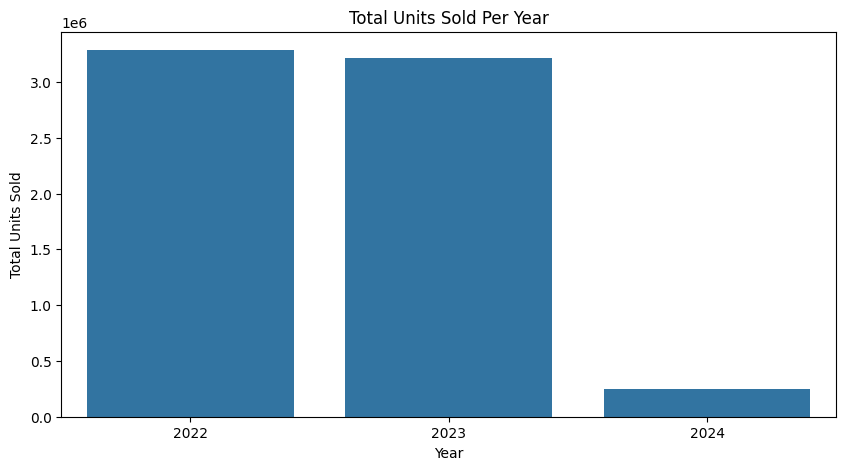

In [312]:
yearly_sales = df.groupby('Year')['Units Sold'].sum()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values
)

plt.title('Total Units Sold Per Year')
plt.xlabel('Year')
plt.ylabel('Total Units Sold')

plt.show()

#Revenue Per Year

In [313]:
df['Revenue'] = (
    df['Units Sold'] *
    df['Price'] *
    (1 - df['Discount'] / 100)
)

In [314]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
yearly_revenue = df.groupby('Year')['Revenue'].sum()
print("Yearly Earnings:")
print(yearly_revenue.round(2))

Yearly Earnings:
Year
2022    2.012313e+08
2023    1.961494e+08
2024    1.520993e+07
Name: Revenue, dtype: float64


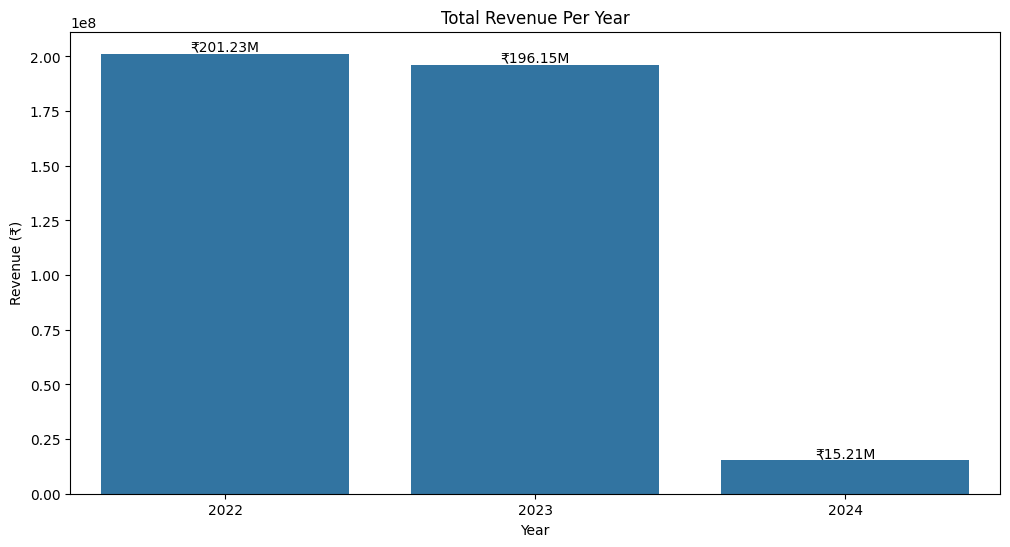

In [315]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=yearly_revenue.index,
    y=yearly_revenue.values
)

for i, value in enumerate(yearly_revenue.values):
    ax.text(
        i,
        value,
        f'₹{value/1_000_000:.2f}M',
        ha='center',
        va='bottom'
    )

plt.title('Total Revenue Per Year')
plt.xlabel('Year')
plt.ylabel('Revenue (₹)')

plt.show()

In [316]:
yearly_summary = yearly_revenue.reset_index()
yearly_summary.columns = ['Year', 'Total Revenue']
yearly_summary['Total Revenue'] = (
    yearly_summary['Total Revenue'].round(2)
)
display(yearly_summary)

,Year,Total Revenue
0,2022,2.012313e+08
1,2023,1.961494e+08
2,2024,1.520993e+07


#Revenue Per Region


In [317]:
region_revenue = (
    df.groupby('Region')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by Region:")
print(region_revenue.round(2))

Revenue by Region:
Region
North    1.541444e+08
East     8.925563e+07
West     8.559825e+07
South    8.359233e+07
Name: Revenue, dtype: float64


In [318]:
region_summary = region_revenue.reset_index()

region_summary.columns = ['Region', 'Total Revenue']

region_summary['Total Revenue'] = region_summary['Total Revenue'].round(2)

display(region_summary)

,Region,Total Revenue
0,North,1.541444e+08
1,East,8.925563e+07
2,West,8.559825e+07
3,South,8.359233e+07


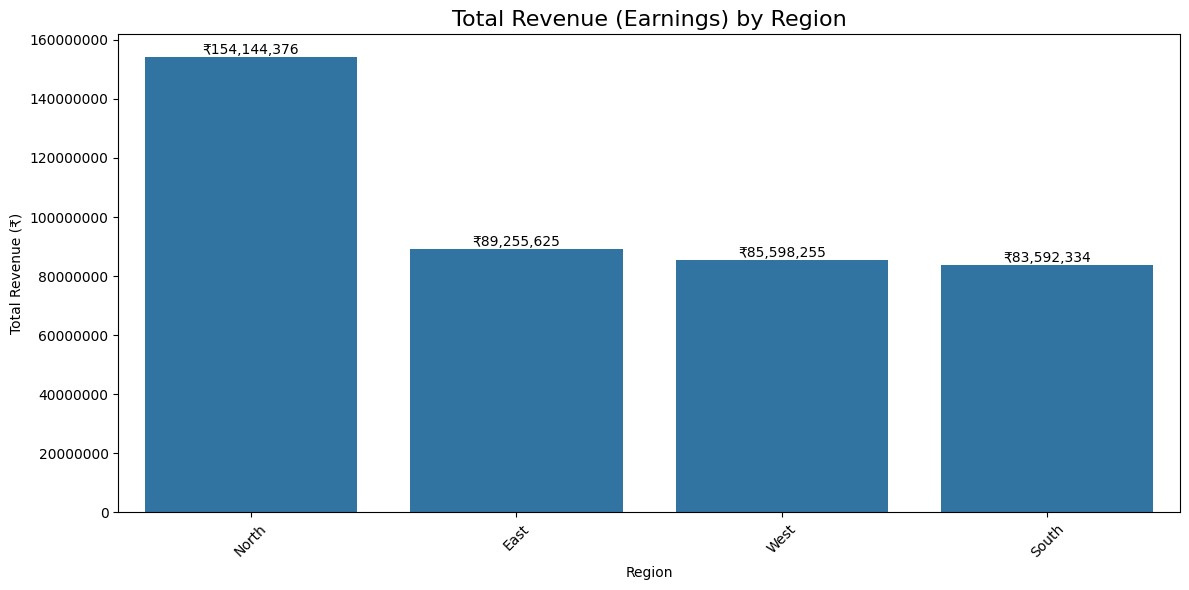

In [319]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=region_revenue.index,
    y=region_revenue.values
)
# Add exact earnings on each bar
for i, value in enumerate(region_revenue.values):
    ax.text(
        i,
        value,
        f'₹{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title('Total Revenue (Earnings) by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Total Revenue (₹)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [320]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'Revenue',
       'Inventory Group'],
      dtype='object')

#Revenue Per Store And Top Store

In [321]:
store_revenue = (
    df.groupby('Store ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print(store_revenue.round(2))

Store ID
S003    89255625.46
S004    85598254.71
S002    83592333.88
S001    81555358.44
S005    72589017.34
Name: Revenue, dtype: float64


In [322]:
store_summary = store_revenue.reset_index()

store_summary.columns = ['Store ID', 'Total Revenue']

store_summary['Total Revenue'] = (
    store_summary['Total Revenue'].round(2)
)

display(store_summary)

,Store ID,Total Revenue
0,S003,89255625.46
1,S004,85598254.71
2,S002,83592333.88
3,S001,81555358.44
4,S005,72589017.34


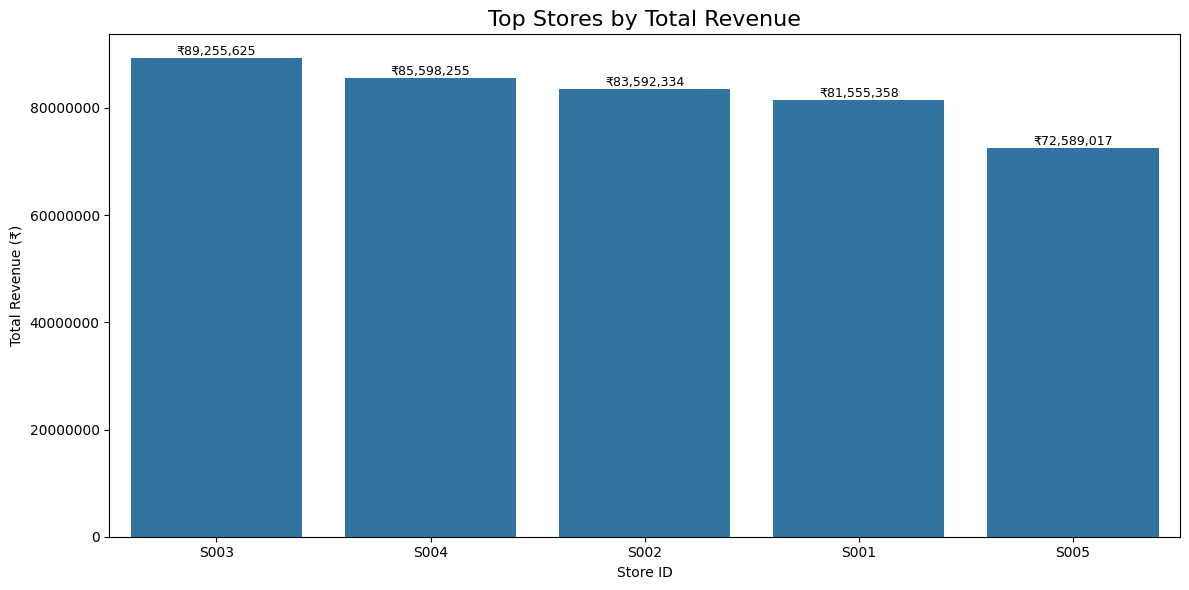

In [323]:
top_stores = store_revenue.head(10)
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=top_stores.index,
    y=top_stores.values
)
# Add exact earnings above each bar
for i, value in enumerate(top_stores.values):
    ax.text(
        i,
        value,
        f'₹{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.title('Top Stores by Total Revenue', fontsize=16)
plt.xlabel('Store ID')
plt.ylabel('Total Revenue (₹)')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [324]:
top__summary = store_revenue.head(10).reset_index()

top__summary.columns = ['Store ID', 'Revenue']

top__summary['Revenue'] = top__summary['Revenue'].apply(
    lambda x: f'₹{x:,.2f}'
)

display(top__summary)

,Store ID,Revenue
0,S003,"₹89,255,625.47"
1,S004,"₹85,598,254.71"
2,S002,"₹83,592,333.88"
3,S001,"₹81,555,358.44"
4,S005,"₹72,589,017.34"


#Units Sold By category

In [325]:
category_sales = (
    df.groupby('Category')['Units Sold']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Groceries      3127335
Clothing       1150873
Furniture       880654
Toys            834679
Electronics     757335
Name: Units Sold, dtype: int64


In [326]:
category_sales_summary = category_sales.reset_index()

category_sales_summary.columns = ['Category', 'Total Units Sold']

display(category_sales_summary)

,Category,Total Units Sold
0,Groceries,3127335
1,Clothing,1150873
2,Furniture,880654
3,Toys,834679
4,Electronics,757335


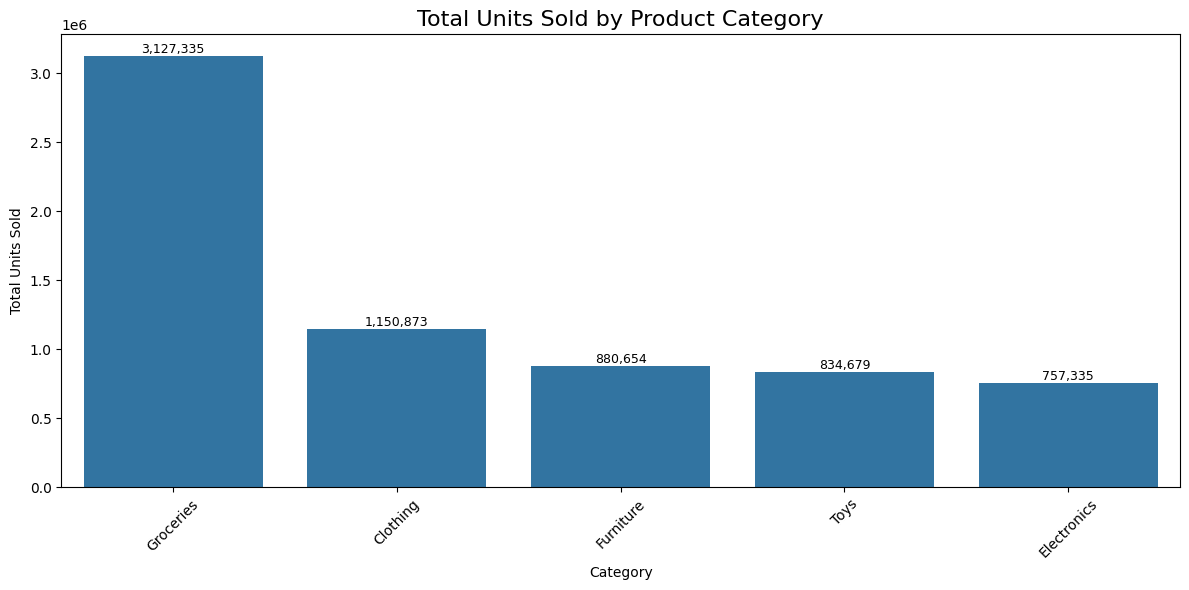

In [327]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

# Add exact figures
for i, value in enumerate(category_sales.values):
    ax.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Total Units Sold by Product Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Units Sold')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [328]:
categorical_cols = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Weather Condition',
    'Promotion',
    'Seasonality',
    'Epidemic'
]

for col in categorical_cols:
    print(f"\n{'='*40}")
    print(f"Frequency of {col}")
    print('='*40)

    print(df[col].value_counts().head(10))


Frequency of Store ID
Store ID
S001    15200
S002    15200
S003    15200
S004    15200
S005    15200
Name: count, dtype: int64

Frequency of Product ID
Product ID
P0001    3800
P0002    3800
P0003    3800
P0004    3800
P0005    3800
P0006    3800
P0007    3800
P0008    3800
P0009    3800
P0010    3800
Name: count, dtype: int64

Frequency of Category
Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64

Frequency of Region
Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64

Frequency of Weather Condition
Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64

Frequency of Promotion
Promotion
0    51000
1    25000
Name: count, dtype: int64

Frequency of Seasonality
Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64

Frequency of Epidemic
Epidemic
0    60800


In [329]:
store_frequency = df['Store ID'].value_counts()

print(store_frequency.head(10))

Store ID
S001    15200
S002    15200
S003    15200
S004    15200
S005    15200
Name: count, dtype: int64


In [330]:
promotion_revenue = (
    df.groupby('Promotion')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Total Revenue by Promotion:")
print(promotion_revenue.round(2))

Total Revenue by Promotion:
Promotion
0    2.720829e+08
1    1.405077e+08
Name: Revenue, dtype: float64


In [331]:
promotion_summary = (
    df.groupby('Promotion')['Revenue']
    .agg(
        Transactions='count',
        Total_Revenue='sum',
        Average_Revenue='mean'
    )
    .sort_values('Total_Revenue', ascending=False)
)

promotion_summary = promotion_summary.round(2)

display(promotion_summary)

,Transactions,Total_Revenue,Average_Revenue
Promotion,,,
0,51000,2.720829e+08,5334.96
1,25000,1.405077e+08,5620.31


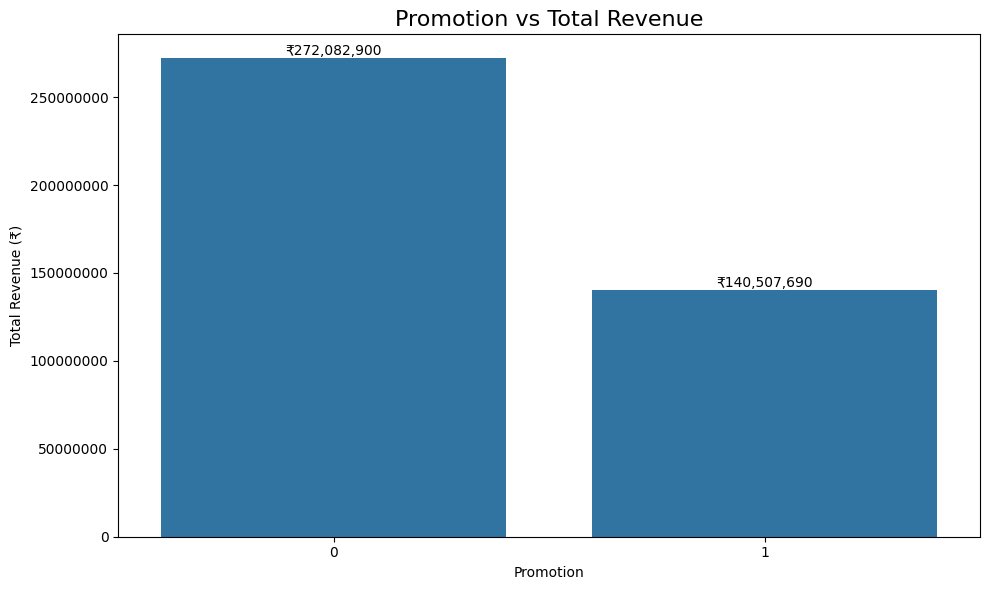

In [332]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=promotion_revenue.index,
    y=promotion_revenue.values
)

# Add exact revenue
for i, value in enumerate(promotion_revenue.values):
    ax.text(
        i,
        value,
        f'₹{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Promotion vs Total Revenue', fontsize=16)
plt.xlabel('Promotion')
plt.ylabel('Total Revenue (₹)')

plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

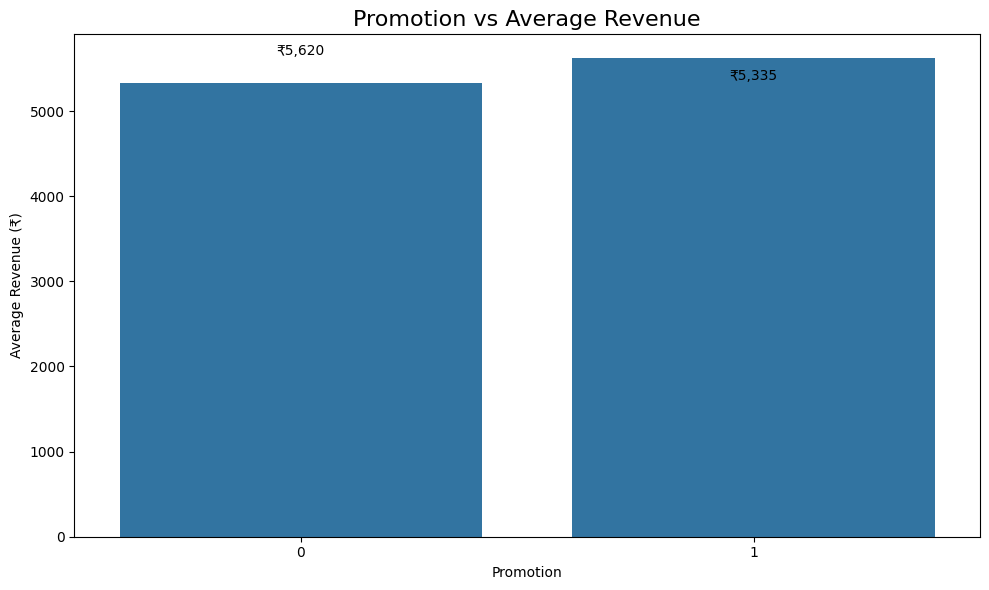

In [333]:
avg_promotion_revenue = (
    df.groupby('Promotion')['Revenue']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=avg_promotion_revenue.index,
    y=avg_promotion_revenue.values
)

for i, value in enumerate(avg_promotion_revenue.values):
    ax.text(
        i,
        value,
        f'₹{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Promotion vs Average Revenue', fontsize=16)
plt.xlabel('Promotion')
plt.ylabel('Average Revenue (₹)')

plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

#Discount

In [334]:
print(df['Discount'].describe())
print(df['Discount'].value_counts().sort_index())

count    76000.000000
mean         9.087039
std          7.475781
min          0.000000
25%          5.000000
50%         10.000000
75%         10.000000
max         25.000000
Name: Discount, dtype: float64
Discount
0     17126
5     16918
10    23298
15     6245
20     6191
25     6222
Name: count, dtype: int64


In [335]:
discount_sales = (
    df.groupby('Discount')['Units Sold']
    .mean()
    .sort_index()
)
print(discount_sales.round(2))

Discount
0      81.57
5      81.69
10     87.66
15    102.88
20    103.77
25    103.59
Name: Units Sold, dtype: float64


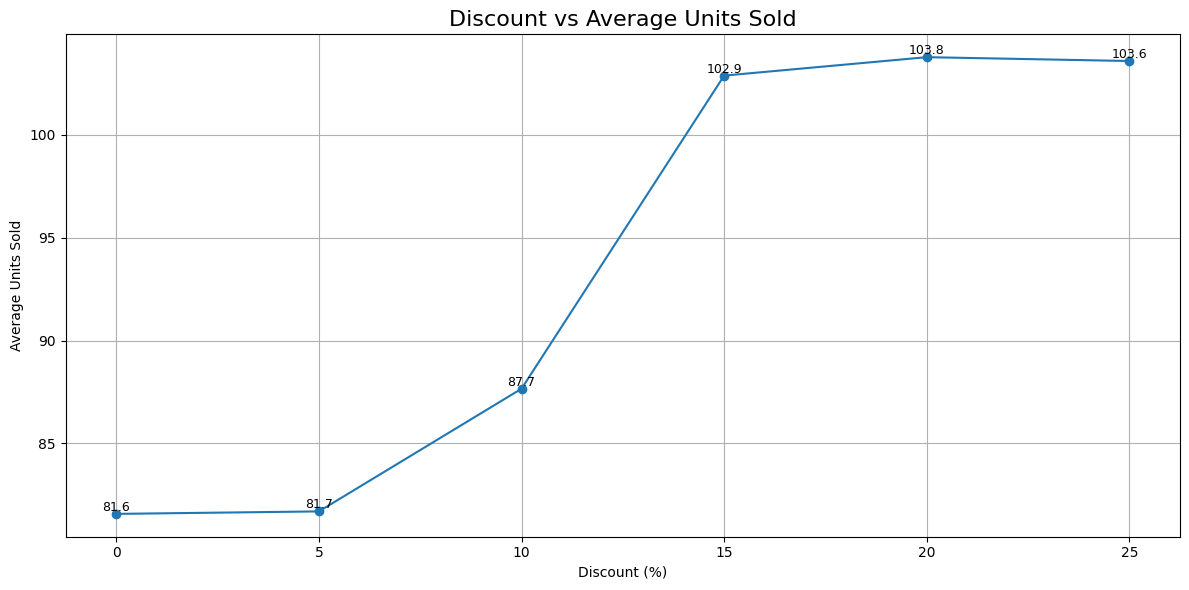

In [336]:
plt.figure(figsize=(12, 6))

plt.plot(
    discount_sales.index,
    discount_sales.values,
    marker='o'
)

# Add exact values
for x, y in zip(discount_sales.index, discount_sales.values):
    plt.text(
        x,
        y,
        f'{y:.1f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Discount vs Average Units Sold', fontsize=16)
plt.xlabel('Discount (%)')
plt.ylabel('Average Units Sold')

plt.grid(True)
plt.tight_layout()
plt.show()


#The Discount vs Average Units Sold analysis shows that sales increase as discount rates rise, particularly between 10% and 15%. Average units sold reaches its maximum at approximately 20% discount. Beyond this point, increasing the discount to 25% does not result in additional sales growth, indicating diminishing returns. Therefore, excessive discounting may not be beneficial for the business

In [337]:
correlation = df['Discount'].corr(df['Units Sold'])
print("Correlation between Discount and Units Sold:", round(correlation, 3))

Correlation between Discount and Units Sold: 0.184


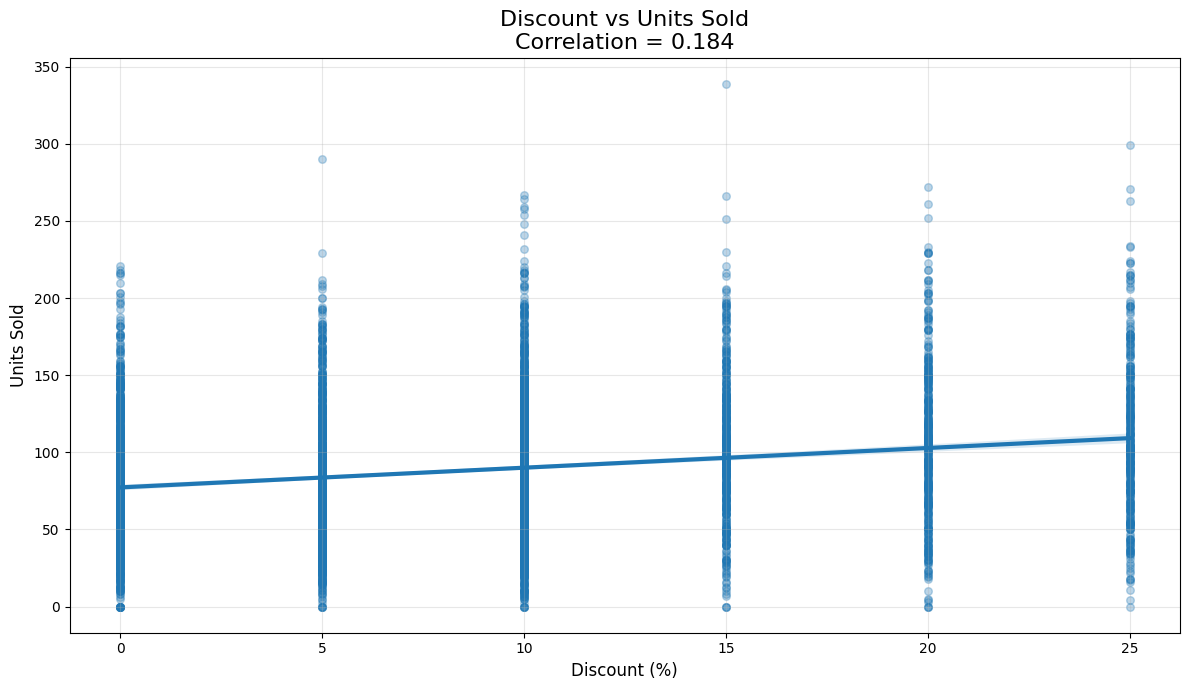

In [338]:
plt.figure(figsize=(12, 7))

sample_df = df.sample(5000, random_state=42)

sns.regplot(
    data=sample_df,
    x='Discount',
    y='Units Sold',
    scatter_kws={'alpha': 0.3, 's': 30},
    line_kws={'linewidth': 3}
)

# Calculate correlation
corr = df['Discount'].corr(df['Units Sold'])

plt.title(
    f'Discount vs Units Sold\nCorrelation = {corr:.3f}',
    fontsize=16
)

plt.xlabel('Discount (%)', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Demand According to Seasons


In [339]:
season_demand = (
    df.groupby('Seasonality')['Demand']
    .agg(
        Average_Demand='mean',
        Total_Demand='sum',
        Records='count'
    )
    .sort_values('Average_Demand', ascending=False)
)

display(season_demand.round(2))

,Average_Demand,Total_Demand,Records
Seasonality,,,
Summer,112.86,2076539,18400
Autumn,103.42,1882298,18200
Winter,103.41,2171530,21000
Spring,97.70,1797737,18400


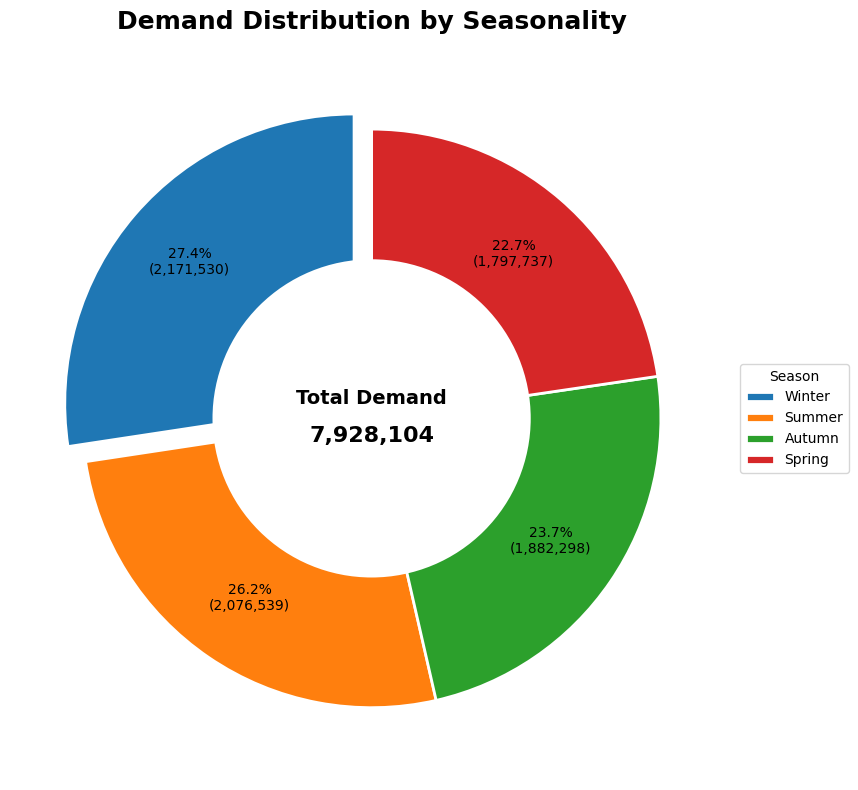

In [340]:
# Calculate total demand by season
season_demand = (
    df.groupby('Seasonality')['Demand']
    .sum()
    .sort_values(ascending=False)
)

labels = season_demand.index
values = season_demand.values

# Explode the largest season
explode = [0.08 if value == values.max() else 0
           for value in values]

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Custom function for percentage + exact value
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        value = int(round(pct * total / 100))
        return f'{pct:.1f}%\n({value:,})'
    return my_format


wedges, texts, autotexts = ax.pie(
    values,
    explode=explode,
    autopct=autopct_format(values),
    startangle=90,
    pctdistance=0.75,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    }
)

# Create donut effect
centre_circle = plt.Circle(
    (0, 0),
    0.55,
    fc='white'
)

ax.add_artist(centre_circle)

# Add total demand in center
ax.text(
    0, 0.05,
    'Total Demand',
    ha='center',
    fontsize=14,
    fontweight='bold'
)

ax.text(
    0, -0.08,
    f'{values.sum():,}',
    ha='center',
    fontsize=16,
    fontweight='bold'
)

# Legend
ax.legend(
    wedges,
    labels,
    title='Season',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.title(
    'Demand Distribution by Seasonality',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

In [341]:
weather_sales = (
    df.groupby('Weather Condition')['Units Sold']
    .agg(
        Average_Units_Sold='mean',
        Total_Units_Sold='sum',
        Records='count'
    )
    .sort_values('Average_Units_Sold', ascending=False)
)

display(weather_sales.round(2))

,Average_Units_Sold,Total_Units_Sold,Records
Weather Condition,,,
Sunny,97.03,2229702,22980
Cloudy,89.63,2183274,24360
Rainy,81.97,1434515,17500
Snowy,80.95,903385,11160


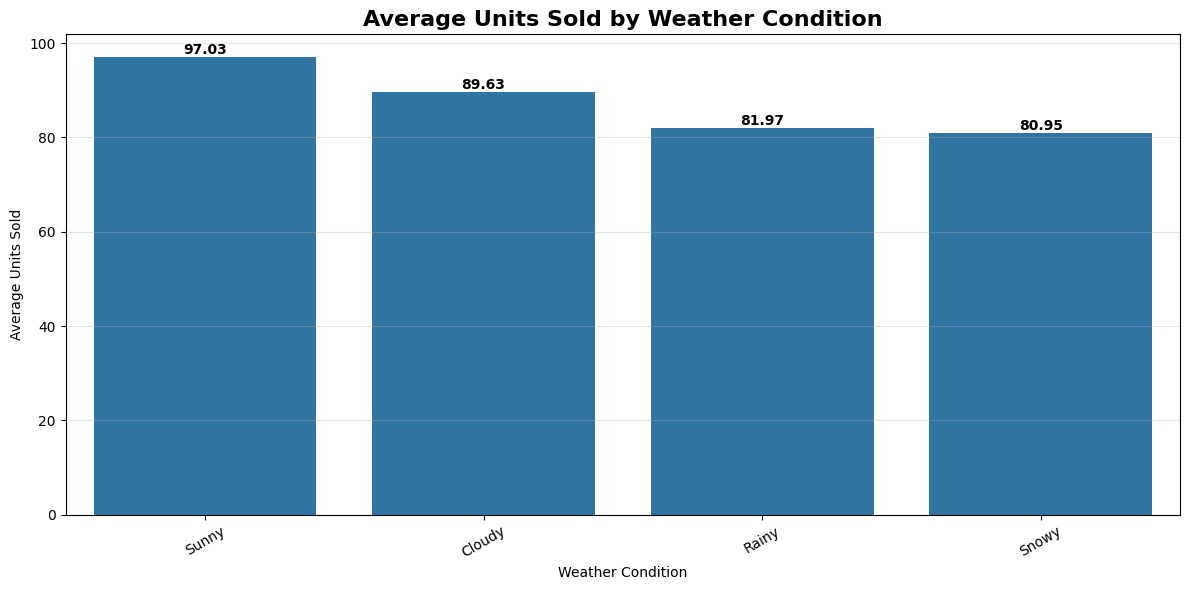

In [342]:
plt.figure(figsize=(12, 6))

weather_avg = (
    df.groupby('Weather Condition')['Units Sold']
    .mean()
    .sort_values(ascending=False)
)

ax = sns.barplot(
    x=weather_avg.index,
    y=weather_avg.values
)

# Add exact values
for i, value in enumerate(weather_avg.values):
    ax.text(
        i,
        value,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Average Units Sold by Weather Condition',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Weather Condition')
plt.ylabel('Average Units Sold')

plt.grid(axis='y', alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

#Revenue Generated According to Weather


In [343]:
weather_revenue = (
    df.groupby('Weather Condition')['Revenue']
    .agg(
        Total_Revenue='sum',
        Average_Revenue='mean',
        Transactions='count'
    )
    .sort_values('Total_Revenue', ascending=False)
)

display(weather_revenue.round(2))

,Total_Revenue,Average_Revenue,Transactions
Weather Condition,,,
Sunny,1.416104e+08,6162.33,22980
Cloudy,1.333317e+08,5473.39,24360
Rainy,8.390396e+07,4794.51,17500
Snowy,5.374454e+07,4815.82,11160


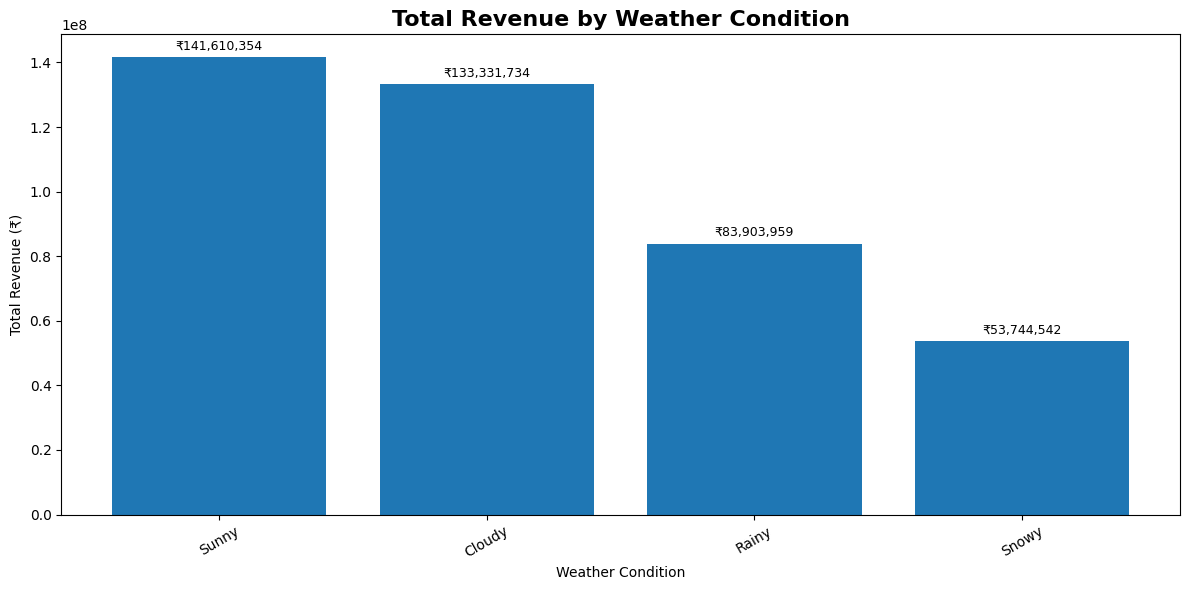

In [344]:
weather_rev = (
    df.groupby('Weather Condition')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    weather_rev.index,
    weather_rev.values
)

# Exact values
ax.bar_label(
    bars,
    labels=[f'₹{x:,.0f}' for x in weather_rev.values],
    padding=3,
    fontsize=9
)

ax.set_title(
    'Total Revenue by Weather Condition',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Weather Condition')
ax.set_ylabel('Total Revenue (₹)')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

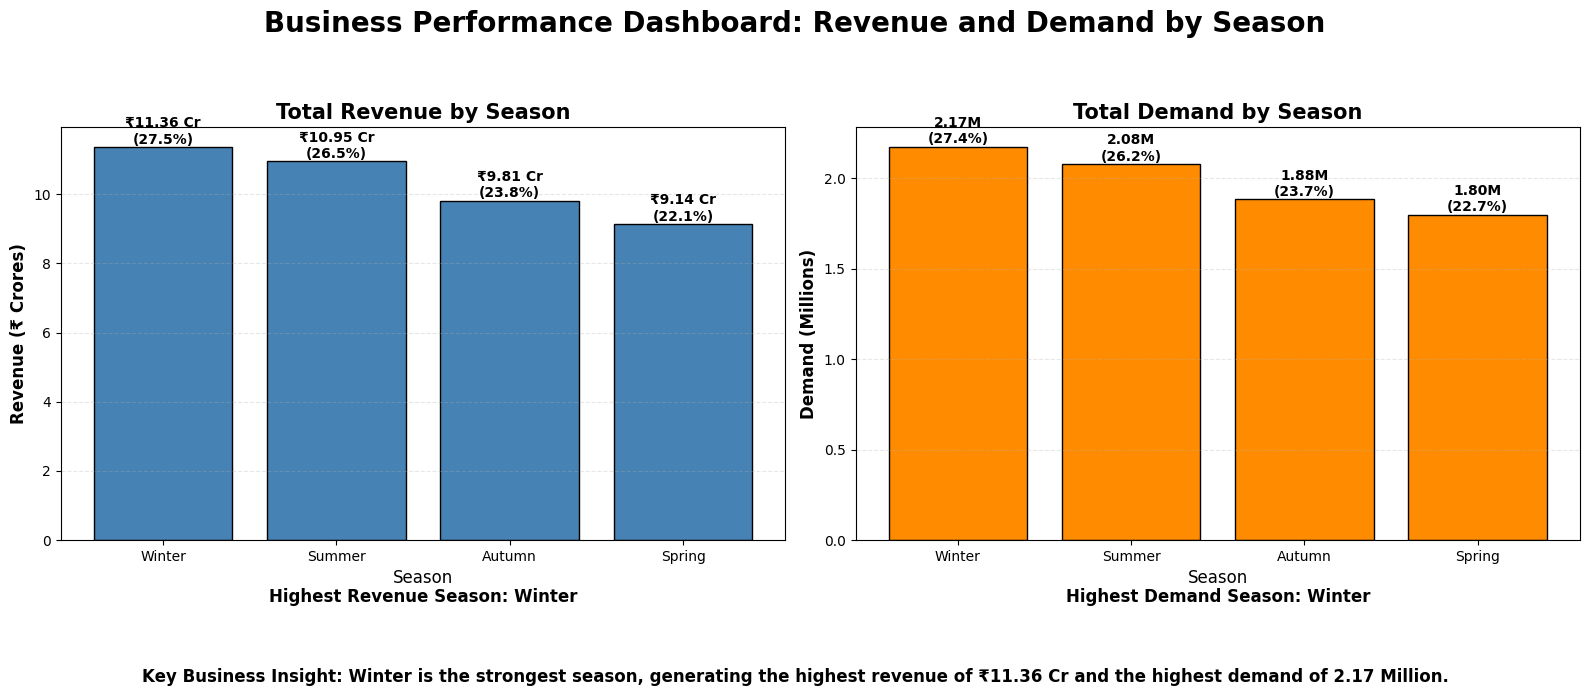

In [345]:
def plot_business_dashboard(df):

    data = df.groupby('Seasonality').agg(
        Revenue=('Revenue', 'sum'),
        Demand=('Demand', 'sum')
    )

    season_order = ['Winter', 'Summer', 'Autumn', 'Spring']

    data = data.reindex(
        [season for season in season_order if season in data.index]
    )

    data['Revenue %'] = (
        data['Revenue'] / data['Revenue'].sum() * 100
    )

    data['Demand %'] = (
        data['Demand'] / data['Demand'].sum() * 100
    )

    best_season = data['Revenue'].idxmax()
    highest_demand = data['Demand'].idxmax()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    fig.suptitle(
        'Business Performance Dashboard: Revenue and Demand by Season',
        fontsize=20,
        fontweight='bold',
        y=0.98
    )

    ax1 = axes[0]

    bars1 = ax1.bar(
        data.index,
        data['Revenue'] / 1e7,
        color='steelblue',
        edgecolor='black',
        linewidth=1
    )

    for bar, value, percent in zip(
        bars1,
        data['Revenue'],
        data['Revenue %']
    ):

        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'₹{value/1e7:.2f} Cr\n({percent:.1f}%)',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    ax1.set_title(
        'Total Revenue by Season',
        fontsize=15,
        fontweight='bold'
    )

    ax1.set_xlabel('Season', fontsize=12)
    ax1.set_ylabel(
        'Revenue (₹ Crores)',
        fontsize=12,
        fontweight='bold'
    )

    ax1.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax1.text(
        0.5,
        -0.15,
        f'Highest Revenue Season: {best_season}',
        transform=ax1.transAxes,
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

    ax2 = axes[1]

    bars2 = ax2.bar(
        data.index,
        data['Demand'] / 1e6,
        color='darkorange',
        edgecolor='black',
        linewidth=1
    )

    for bar, value, percent in zip(
        bars2,
        data['Demand'],
        data['Demand %']
    ):

        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{value/1e6:.2f}M\n({percent:.1f}%)',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    ax2.set_title(
        'Total Demand by Season',
        fontsize=15,
        fontweight='bold'
    )

    ax2.set_xlabel('Season', fontsize=12)
    ax2.set_ylabel(
        'Demand (Millions)',
        fontsize=12,
        fontweight='bold'
    )

    ax2.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax2.text(
        0.5,
        -0.15,
        f'Highest Demand Season: {highest_demand}',
        transform=ax2.transAxes,
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

    best_revenue = data.loc[best_season, 'Revenue']
    best_demand = data.loc[best_season, 'Demand']

    fig.text(
        0.5,
        0.02,
        f'Key Business Insight: {best_season} is the strongest season, '
        f'generating the highest revenue of ₹{best_revenue/1e7:.2f} Cr '
        f'and the highest demand of {best_demand/1e6:.2f} Million.',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.93])
    plt.show()


plot_business_dashboard(df)

#Weather condition Vs Demand


In [346]:
weather_demand = (
    df.groupby('Weather Condition')['Demand']
    .agg(
        Average_Demand='mean',
        Total_Demand='sum',
        Demand_Std='std'
    )
    .sort_values('Average_Demand', ascending=False)
)

display(weather_demand.round(2))

,Average_Demand,Total_Demand,Demand_Std
Weather Condition,,,
Sunny,115.17,2646542,51.09
Cloudy,105.40,2567643,46.65
Rainy,95.11,1664368,42.64
Snowy,94.05,1049551,39.52


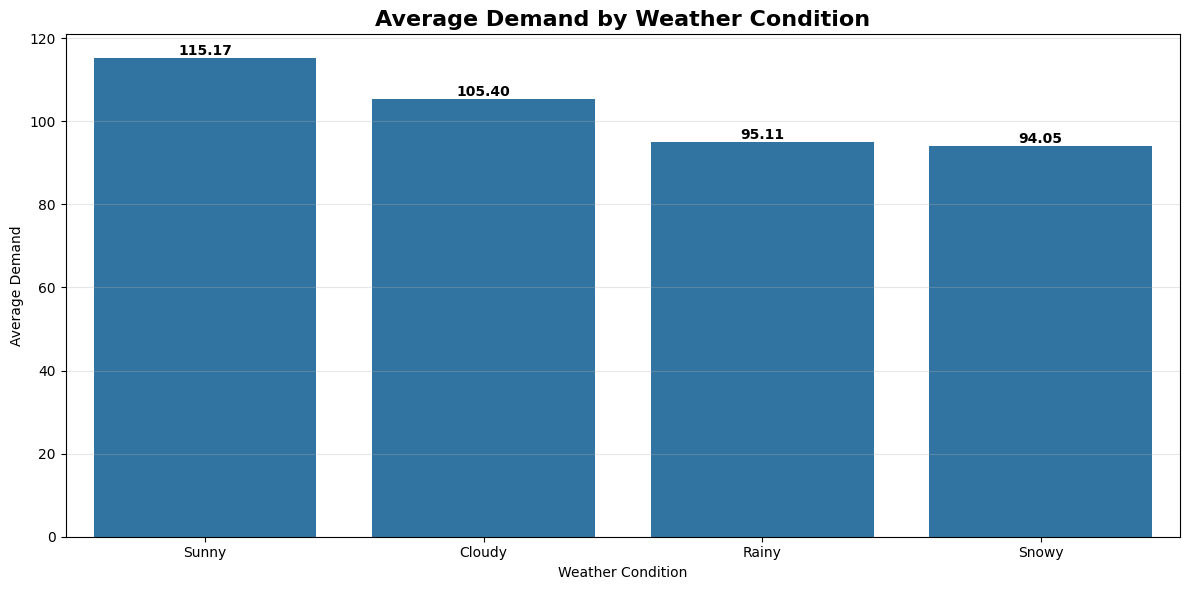

In [347]:
weather_avg_demand = (
    df.groupby('Weather Condition')['Demand']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=weather_avg_demand.index,
    y=weather_avg_demand.values
)

for i, value in enumerate(weather_avg_demand.values):
    ax.text(
        i,
        value,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title(
    'Average Demand by Weather Condition',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Weather Condition')
plt.ylabel('Average Demand')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#Weather vs Units Sold vs Revenue

In [348]:
weather_analysis = (
    df.groupby('Weather Condition')
    .agg(
        Avg_Units_Sold=('Units Sold', 'mean'),
        Avg_Demand=('Demand', 'mean'),
        Avg_Revenue=('Revenue', 'mean')
    )
    .round(2)
)

display(weather_analysis)

,Avg_Units_Sold,Avg_Demand,Avg_Revenue
Weather Condition,,,
Cloudy,89.63,105.40,5473.39
Rainy,81.97,95.11,4794.51
Snowy,80.95,94.05,4815.82
Sunny,97.03,115.17,6162.33


In [349]:
weather_promotion = pd.pivot_table(
    df,
    values='Units Sold',
    index='Weather Condition',
    columns='Promotion',
    aggfunc='mean'
)

display(weather_promotion.round(2))

Promotion,0,1
Weather Condition,,
Cloudy,82.67,103.66
Rainy,75.34,95.60
Snowy,74.35,94.01
Sunny,89.45,112.79


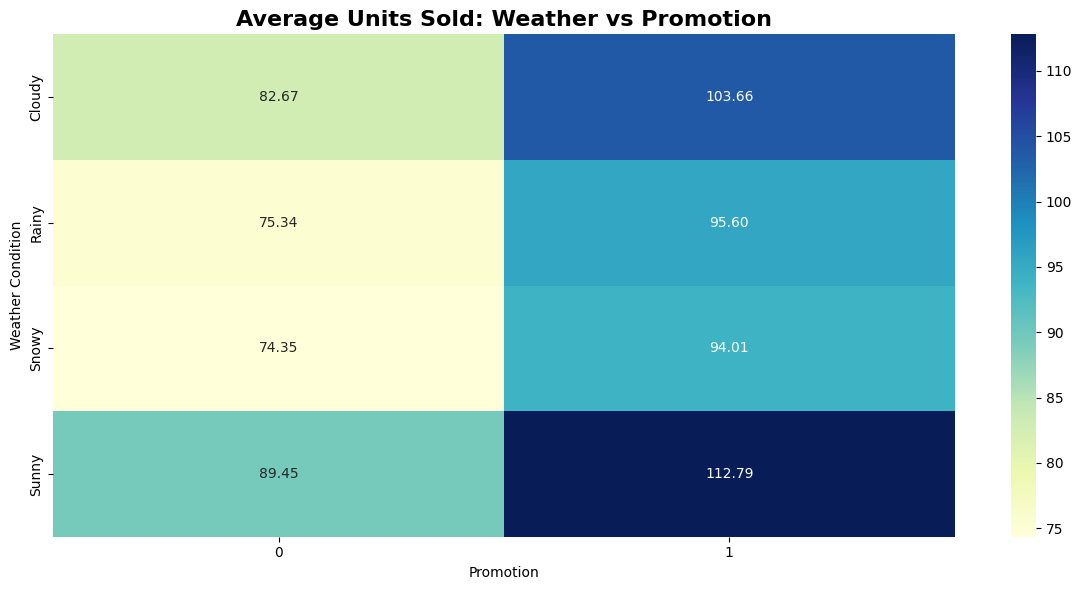

In [350]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    weather_promotion,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title(
    'Average Units Sold: Weather vs Promotion',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Promotion')
plt.ylabel('Weather Condition')

plt.tight_layout()
plt.show()

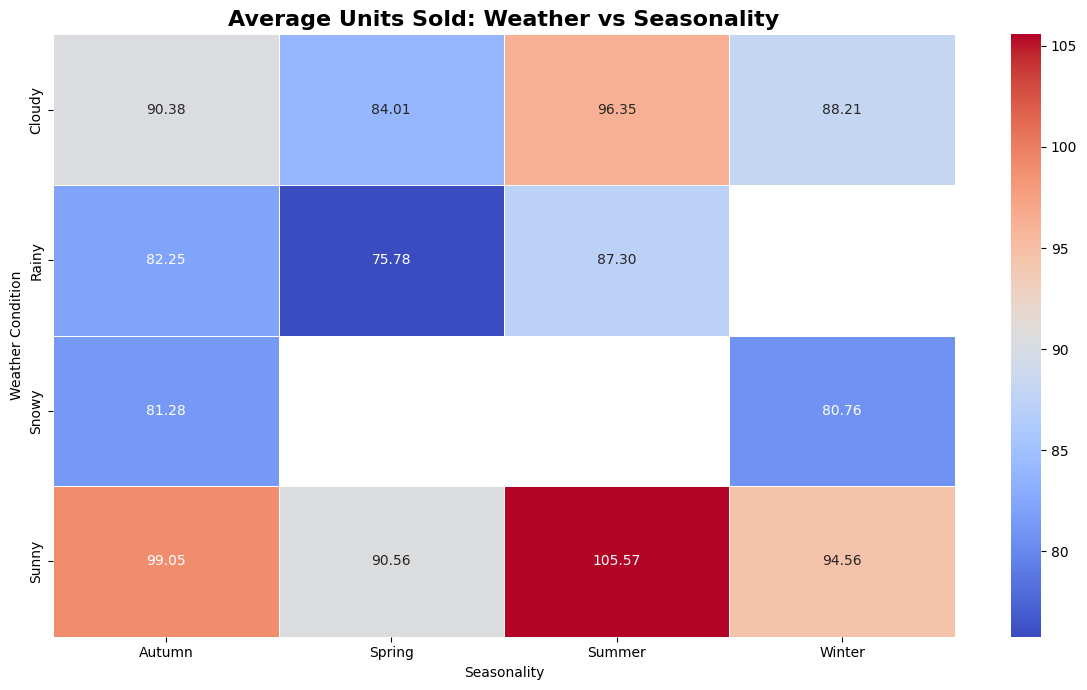

In [351]:
weather_season = pd.pivot_table(
    df,
    values='Units Sold',
    index='Weather Condition',
    columns='Seasonality',
    aggfunc='mean'
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    weather_season,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title(
    'Average Units Sold: Weather vs Seasonality',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Seasonality')
plt.ylabel('Weather Condition')

plt.tight_layout()
plt.show()

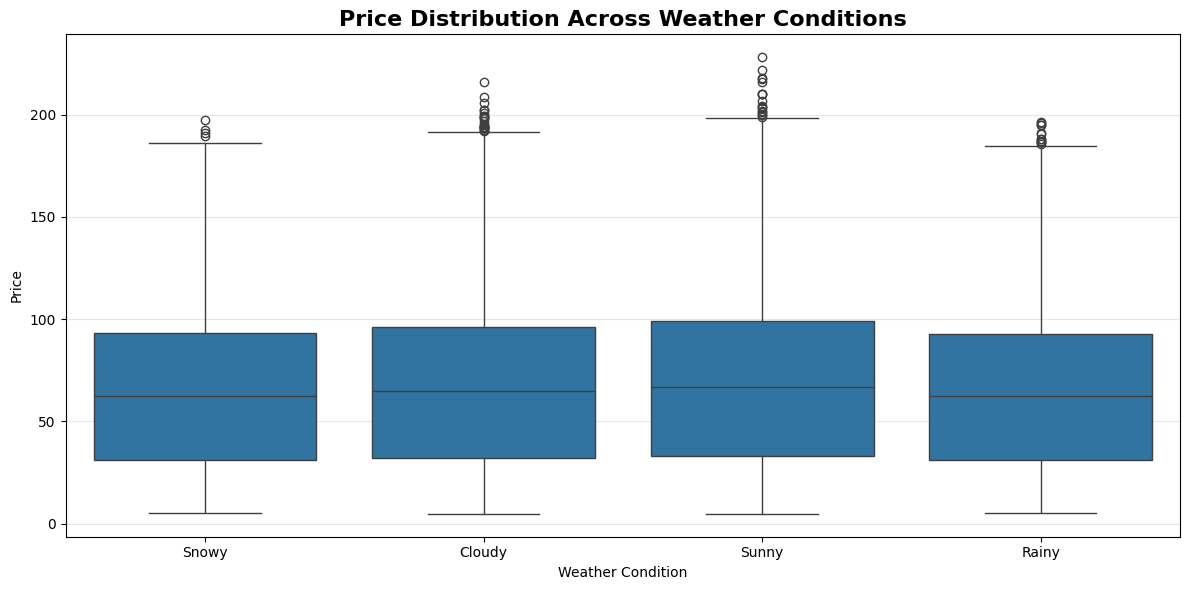

In [352]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Weather Condition',
    y='Price'
)

plt.title(
    'Price Distribution Across Weather Conditions',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Weather Condition')
plt.ylabel('Price')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [353]:
weather_dashboard = (
    df.groupby('Weather Condition')
    .agg(
        Records=('Weather Condition', 'count'),
        Avg_Units_Sold=('Units Sold', 'mean'),
        Total_Units_Sold=('Units Sold', 'sum'),
        Avg_Demand=('Demand', 'mean'),
        Total_Revenue=('Revenue', 'sum'),
        Avg_Revenue=('Revenue', 'mean')
    )
    .sort_values('Total_Revenue', ascending=False)
)

display(weather_dashboard.round(2))

,Records,Avg_Units_Sold,Total_Units_Sold,Avg_Demand,Total_Revenue,Avg_Revenue
Weather Condition,,,,,,
Sunny,22980,97.03,2229702,115.17,1.416104e+08,6162.33
Cloudy,24360,89.63,2183274,105.40,1.333317e+08,5473.39
Rainy,17500,81.97,1434515,95.11,8.390396e+07,4794.51
Snowy,11160,80.95,903385,94.05,5.374454e+07,4815.82


In [354]:
df['Inventory Group'] = pd.qcut(
    df['Inventory Level'],
    q=5,
    duplicates='drop'
)

inventory_analysis = (
    df.groupby('Inventory Group', observed=True)
    .agg(
        Average_Inventory=('Inventory Level', 'mean'),
        Average_Units_Sold=('Units Sold', 'mean'),
        Total_Units_Sold=('Units Sold', 'sum'),
        Average_Demand=('Demand', 'mean')
    )
)

display(inventory_analysis.round(2))

,Average_Inventory,Average_Units_Sold,Total_Units_Sold,Average_Demand
Inventory Group,,,,
"(-0.001, 123.0]",88.36,65.43,1013394,95.52
"(123.0, 183.0]",151.68,89.49,1341566,103.77
"(183.0, 287.0]",230.10,92.27,1395293,103.12
"(287.0, 460.0]",366.21,95.03,1444583,105.39
"(460.0, 2267.0]",670.69,102.40,1556040,113.95


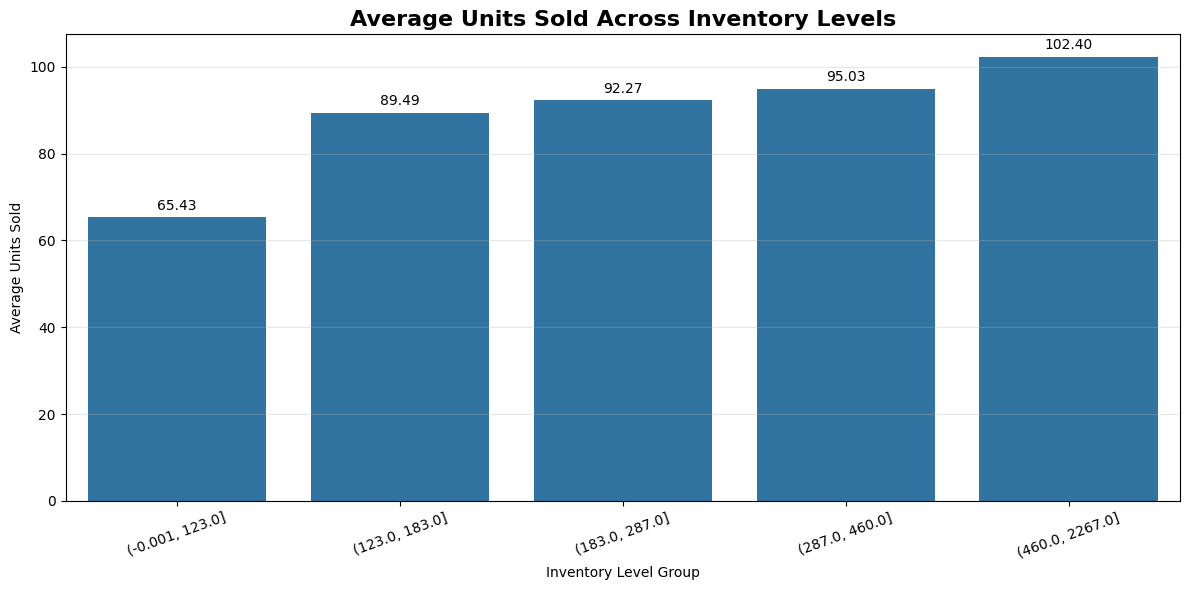

In [355]:
inventory_plot = inventory_analysis.reset_index()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=inventory_plot,
    x='Inventory Group',
    y='Average_Units_Sold'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.title(
    'Average Units Sold Across Inventory Levels',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Inventory Level Group')
plt.ylabel('Average Units Sold')

plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [356]:
inventory_demand_corr = df['Inventory Level'].corr(df['Demand'])

print(
    "Correlation between Inventory Level and Demand:",
    round(inventory_demand_corr, 3)
)

Correlation between Inventory Level and Demand: 0.127


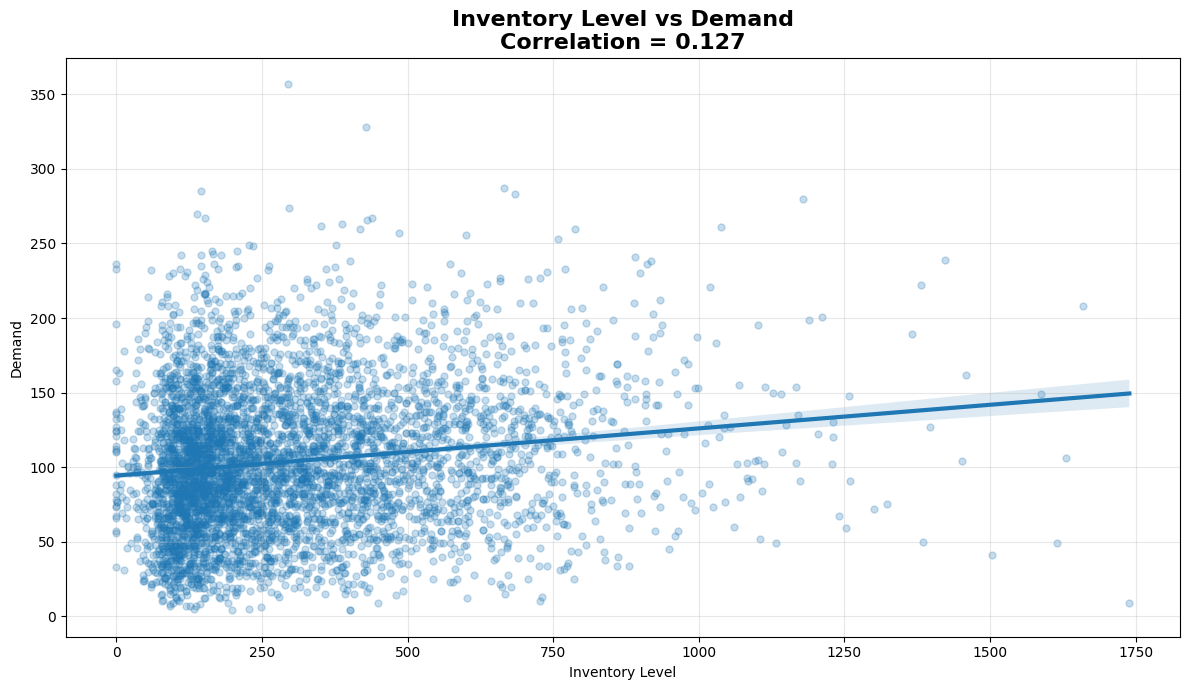

In [357]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(12, 7))

sns.regplot(
    data=sample_df,
    x='Inventory Level',
    y='Demand',
    scatter_kws={'alpha': 0.25, 's': 25},
    line_kws={'linewidth': 3}
)

plt.title(
    f'Inventory Level vs Demand\nCorrelation = {inventory_demand_corr:.3f}',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Inventory Level')
plt.ylabel('Demand')

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

#Epidemic vs Buisness performance


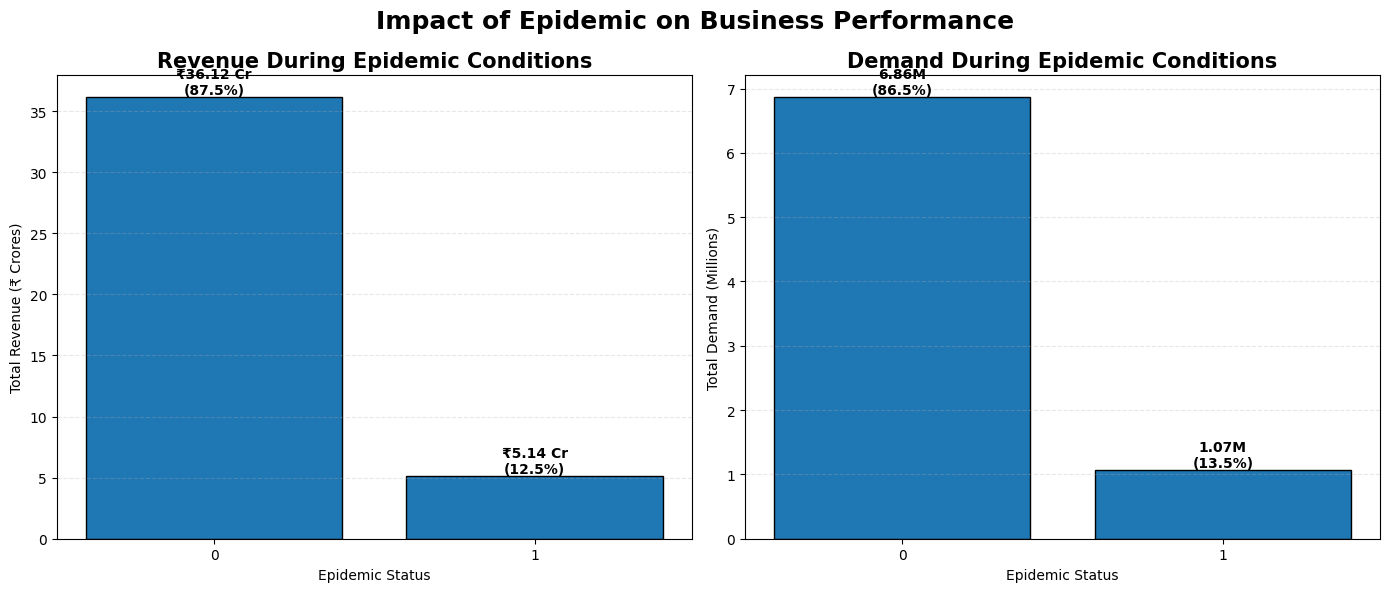

In [358]:
def plot_epidemic_impact(df):

    data = df.groupby('Epidemic').agg(
        Revenue=('Revenue', 'sum'),
        Demand=('Demand', 'sum')
    )

    data['Revenue %'] = (
        data['Revenue'] / data['Revenue'].sum() * 100
    )

    data['Demand %'] = (
        data['Demand'] / data['Demand'].sum() * 100
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    bars1 = axes[0].bar(
        data.index.astype(str),
        data['Revenue'] / 1e7,
        edgecolor='black',
        linewidth=1
    )

    for bar, value, percent in zip(
        bars1,
        data['Revenue'],
        data['Revenue %']
    ):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'₹{value/1e7:.2f} Cr\n({percent:.1f}%)',
            ha='center',
            va='bottom',
            fontweight='bold'
        )

    axes[0].set_title(
        'Revenue During Epidemic Conditions',
        fontsize=15,
        fontweight='bold'
    )

    axes[0].set_xlabel('Epidemic Status')
    axes[0].set_ylabel('Total Revenue (₹ Crores)')
    axes[0].grid(axis='y', linestyle='--', alpha=0.3)

    bars2 = axes[1].bar(
        data.index.astype(str),
        data['Demand'] / 1e6,
        edgecolor='black',
        linewidth=1
    )

    for bar, value, percent in zip(
        bars2,
        data['Demand'],
        data['Demand %']
    ):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{value/1e6:.2f}M\n({percent:.1f}%)',
            ha='center',
            va='bottom',
            fontweight='bold'
        )

    axes[1].set_title(
        'Demand During Epidemic Conditions',
        fontsize=15,
        fontweight='bold'
    )

    axes[1].set_xlabel('Epidemic Status')
    axes[1].set_ylabel('Total Demand (Millions)')
    axes[1].grid(axis='y', linestyle='--', alpha=0.3)

    fig.suptitle(
        'Impact of Epidemic on Business Performance',
        fontsize=18,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


plot_epidemic_impact(df)

In [359]:
df.groupby('Epidemic').agg(
    Avg_Revenue=('Revenue', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Avg_Demand=('Demand', 'mean'),
    Total_Demand=('Demand', 'sum'),
    Transactions=('Epidemic', 'count')
)

,Avg_Revenue,Total_Revenue,Avg_Demand,Total_Demand,Transactions
Epidemic,,,,,
0,5940.508305,3.611829e+08,112.856743,6861690,60800
1,3382.084532,5.140768e+07,70.158816,1066414,15200


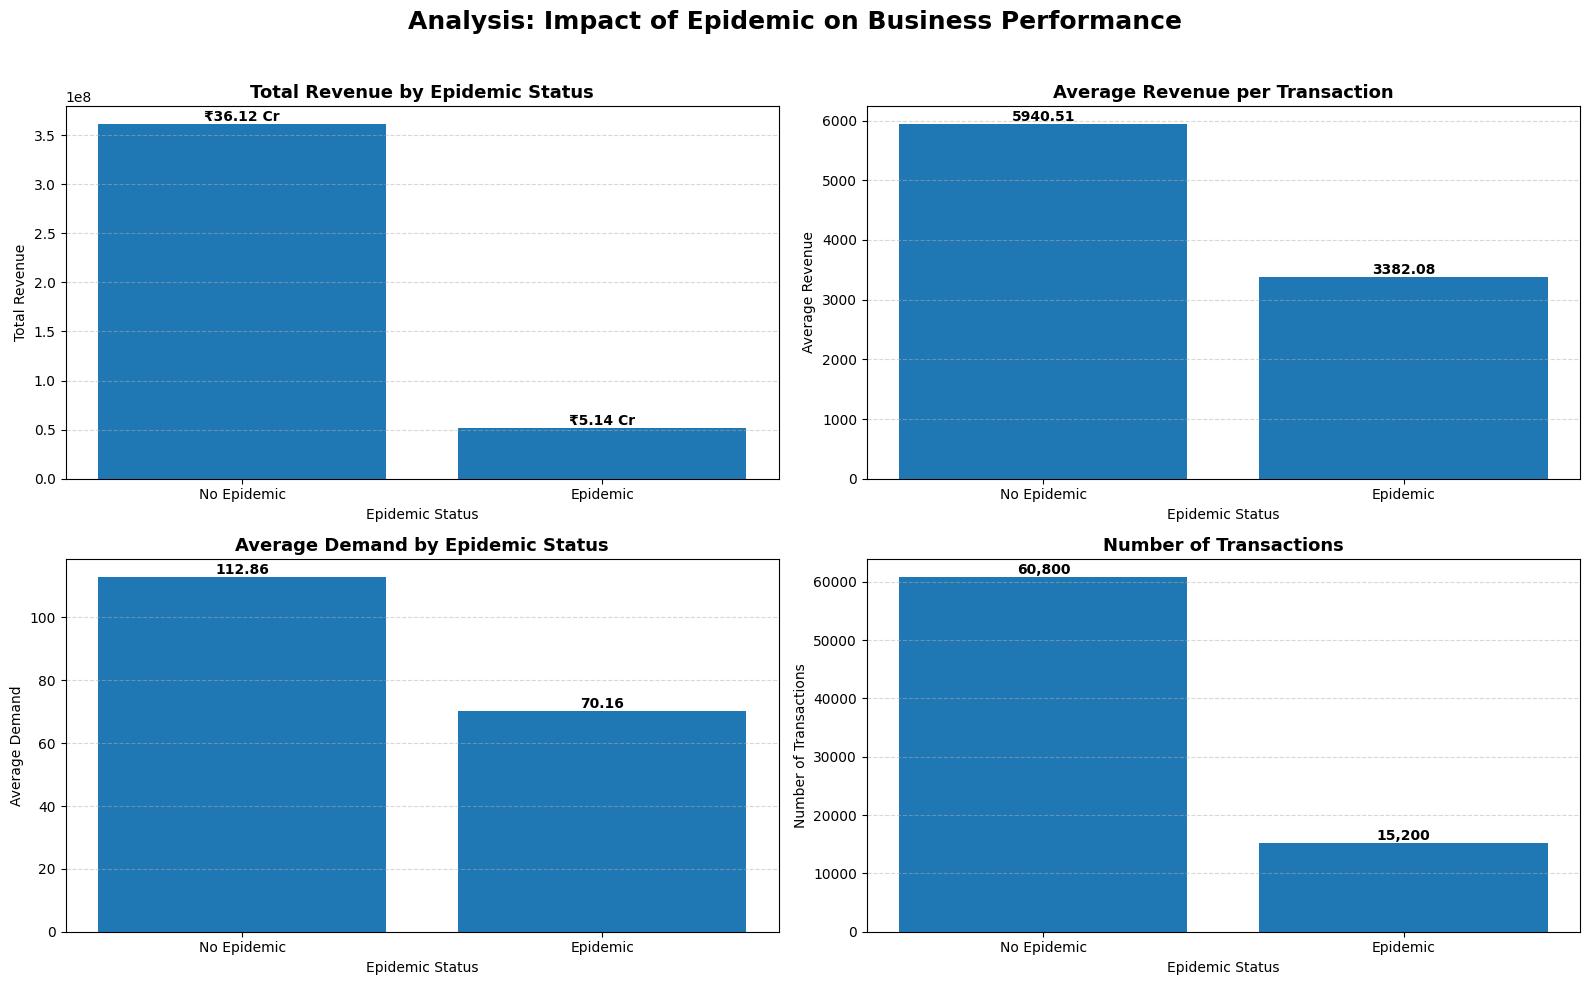

In [360]:
import matplotlib.pyplot as plt

epidemic_summary = df.groupby('Epidemic').agg(
    Avg_Revenue=('Revenue', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Avg_Demand=('Demand', 'mean'),
    Total_Demand=('Demand', 'sum'),
    Transactions=('Epidemic', 'count')
)

epidemic_summary.index = epidemic_summary.index.map({
    0: 'No Epidemic',
    1: 'Epidemic'
})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    'Analysis: Impact of Epidemic on Business Performance',
    fontsize=18,
    fontweight='bold'
)

def add_labels(ax, bars, format_type='normal'):

    for bar in bars:

        height = bar.get_height()

        if format_type == 'crore':
            label = f'₹{height/1e7:.2f} Cr'

        elif format_type == 'million':
            label = f'{height/1e6:.2f} M'

        elif format_type == 'integer':
            label = f'{height:,.0f}'

        else:
            label = f'{height:.2f}'

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            label,
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

bars = axes[0, 0].bar(
    epidemic_summary.index,
    epidemic_summary['Total_Revenue']
)

axes[0, 0].set_title(
    'Total Revenue by Epidemic Status',
    fontsize=13,
    fontweight='bold'
)

axes[0, 0].set_xlabel('Epidemic Status')
axes[0, 0].set_ylabel('Total Revenue')

axes[0, 0].grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

add_labels(axes[0, 0], bars, 'crore')


bars = axes[0, 1].bar(
    epidemic_summary.index,
    epidemic_summary['Avg_Revenue']
)

axes[0, 1].set_title(
    'Average Revenue per Transaction',
    fontsize=13,
    fontweight='bold'
)

axes[0, 1].set_xlabel('Epidemic Status')
axes[0, 1].set_ylabel('Average Revenue')

axes[0, 1].grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

add_labels(axes[0, 1], bars)


bars = axes[1, 0].bar(
    epidemic_summary.index,
    epidemic_summary['Avg_Demand']
)

axes[1, 0].set_title(
    'Average Demand by Epidemic Status',
    fontsize=13,
    fontweight='bold'
)

axes[1, 0].set_xlabel('Epidemic Status')
axes[1, 0].set_ylabel('Average Demand')

axes[1, 0].grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

add_labels(axes[1, 0], bars)


bars = axes[1, 1].bar(
    epidemic_summary.index,
    epidemic_summary['Transactions']
)

axes[1, 1].set_title(
    'Number of Transactions',
    fontsize=13,
    fontweight='bold'
)

axes[1, 1].set_xlabel('Epidemic Status')
axes[1, 1].set_ylabel('Number of Transactions')

axes[1, 1].grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

add_labels(axes[1, 1], bars, 'integer')

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

#Demand Vs Units Solved

In [361]:
demand_sales_corr = df['Demand'].corr(df['Units Sold'])
print(
    "Correlation between Demand and Units Sold:",
    round(demand_sales_corr, 3)
)

Correlation between Demand and Units Sold: 0.833


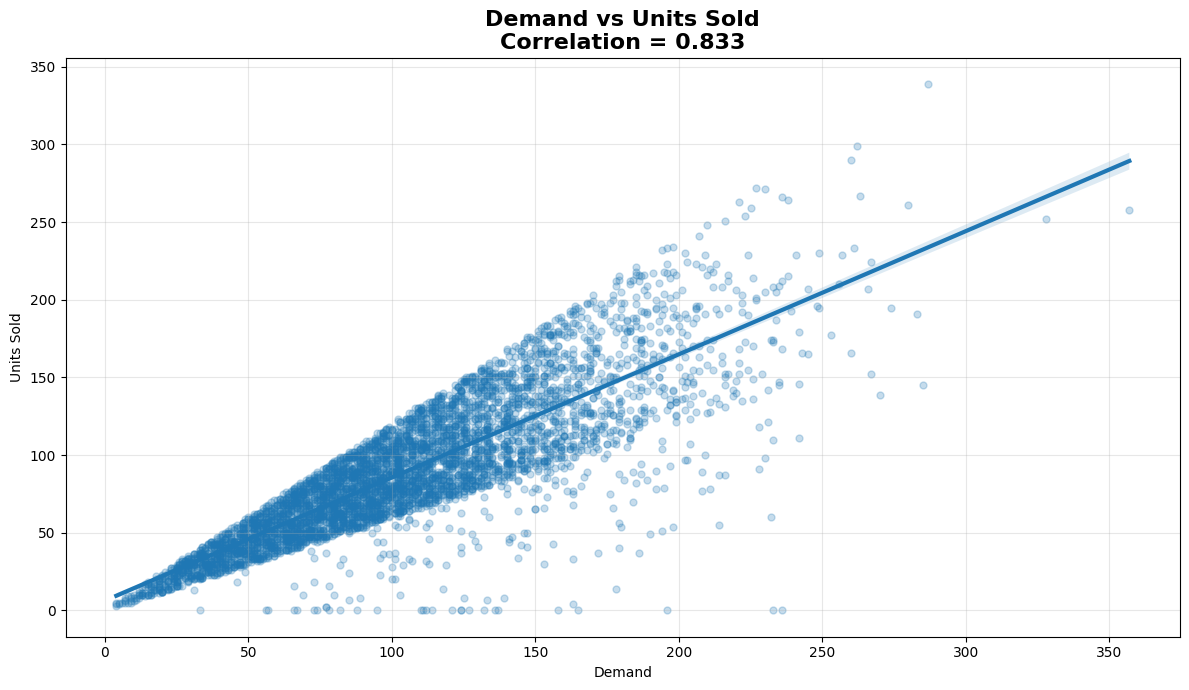

In [362]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(12, 7))

sns.regplot(
    data=sample_df,
    x='Demand',
    y='Units Sold',
    scatter_kws={'alpha': 0.25, 's': 25},
    line_kws={'linewidth': 3}
)

plt.title(
    f'Demand vs Units Sold\nCorrelation = {demand_sales_corr:.3f}',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Demand')
plt.ylabel('Units Sold')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Demand Vs Revenue

In [363]:
demand_revenue_corr = df['Demand'].corr(df['Revenue'])

print(
    "Correlation between Demand and Revenue:",
    round(demand_revenue_corr, 3)
)

Correlation between Demand and Revenue: 0.47


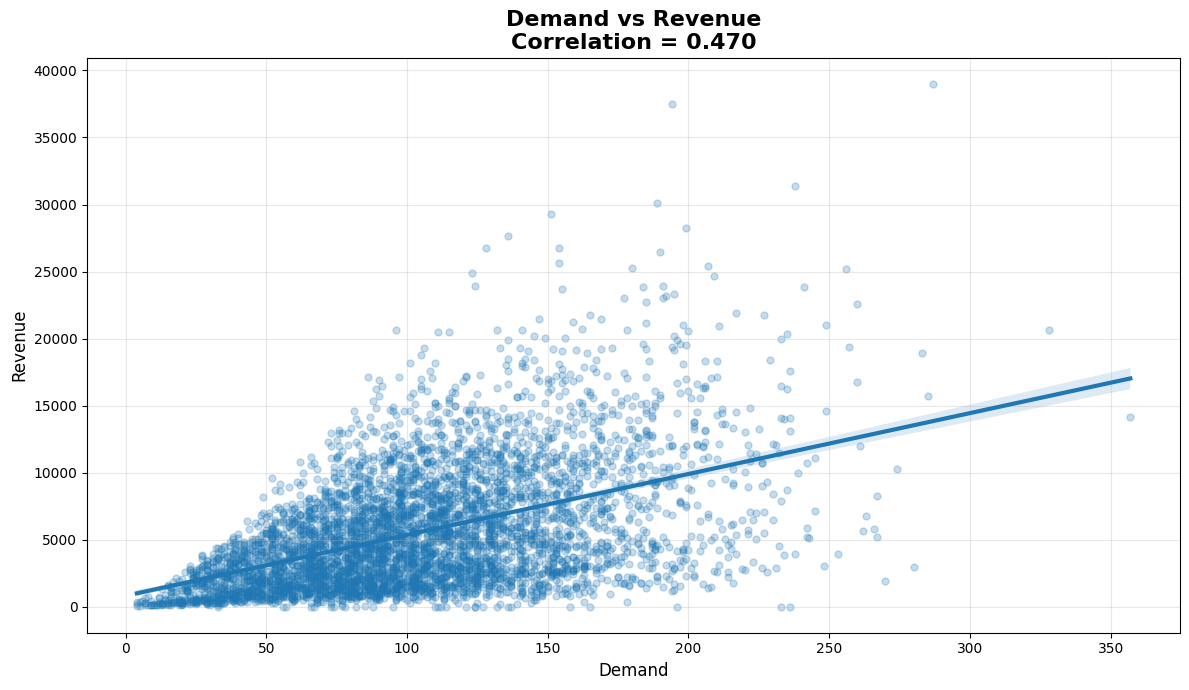

In [364]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(12, 7))

sns.regplot(
    data=sample_df,
    x='Demand',
    y='Revenue',
    scatter_kws={
        'alpha': 0.25,
        's': 25
    },
    line_kws={
        'linewidth': 3
    }
)

plt.title(
    f'Demand vs Revenue\nCorrelation = {demand_revenue_corr:.3f}',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Demand', fontsize=12)
plt.ylabel('Revenue', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

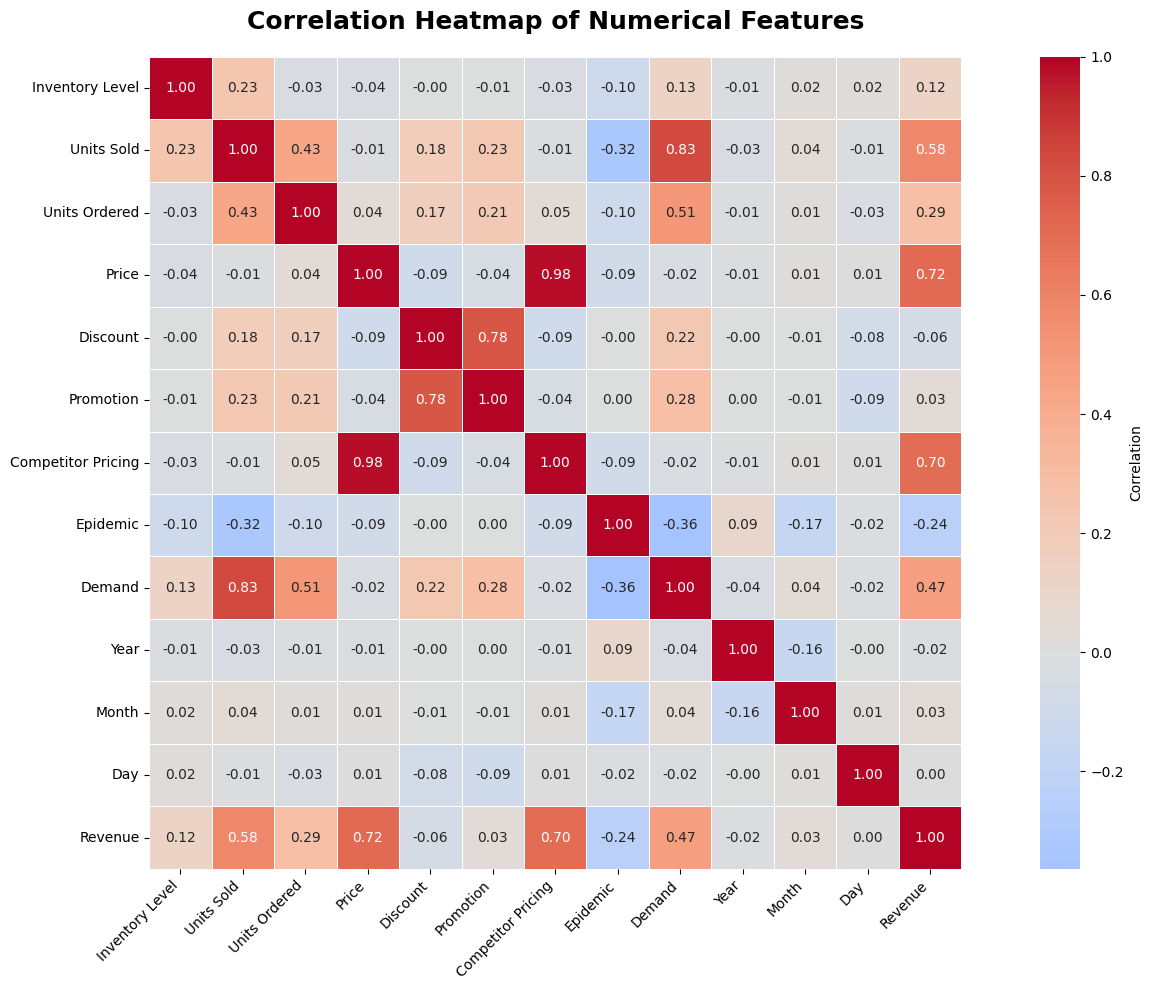

In [365]:


def plot_correlation_heatmap(df):

    numeric_df = df.select_dtypes(include='number')

    correlation = numeric_df.corr()

    plt.figure(figsize=(16, 10))

    sns.heatmap(
        correlation,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        linewidths=0.5,
        square=True,
        cbar_kws={'label': 'Correlation'}
    )

    plt.title(
        'Correlation Heatmap of Numerical Features',
        fontsize=18,
        fontweight='bold',
        pad=20
    )

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(df)

#As Demand increases, Units Sold also tends to increase.

#Outliers Detection --IQR


In [366]:
def detect_outliers(df):

    columns = [
        'Inventory Level',
        'Units Sold',
        'Units Ordered',
        'Price',
        'Discount',
        'Competitor Pricing',
        'Demand',
        'Revenue'
    ]

    results = []

    for column in columns:

        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (df[column] < lower_bound) |
            (df[column] > upper_bound)
        ]

        results.append({
            'Column': column,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Outliers': len(outliers),
            'Outlier %': len(outliers) / len(df) * 100
        })

    return pd.DataFrame(results)

outlier_results = detect_outliers(df)

display(outlier_results.round(2))

,Column,Q1,Q3,IQR,Outliers,Outlier %
0,Inventory Level,136.00,408.00,272.00,2759,3.63
1,Units Sold,58.00,114.00,56.00,1411,1.86
2,Units Ordered,0.00,121.00,121.00,7524,9.90
3,Price,32.00,95.83,63.83,70,0.09
4,Discount,5.00,10.00,5.00,12413,16.33
5,Competitor Pricing,32.62,97.93,65.31,185,0.24
6,Demand,71.00,133.00,62.00,986,1.30
7,Revenue,2199.02,7595.92,5396.90,2209,2.91


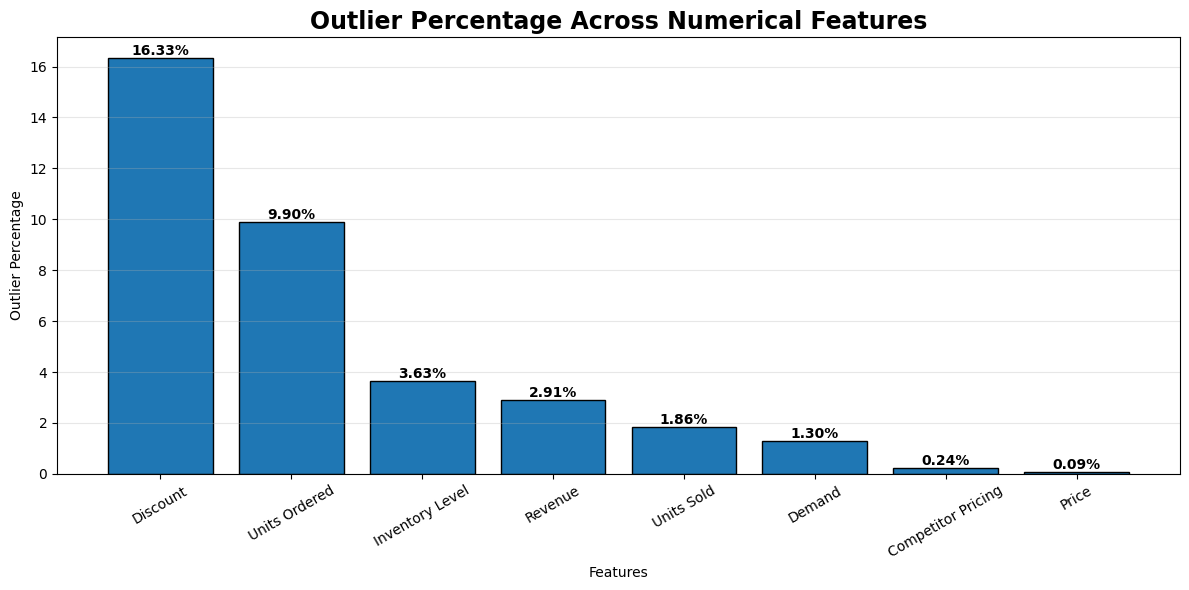

In [367]:
def plot_outliers(outlier_results):
    data = outlier_results.sort_values(
        'Outlier %',
        ascending=False
    )
    plt.figure(figsize=(12, 6))
    bars = plt.bar(
        data['Column'],
        data['Outlier %'],
        edgecolor='black'
    )

    for bar, value in zip(bars, data['Outlier %']):

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{value:.2f}%',
            ha='center',
            va='bottom',
            fontweight='bold'
        )

    plt.title(
        'Outlier Percentage Across Numerical Features',
        fontsize=17,
        fontweight='bold'
    )

    plt.xlabel('Features')
    plt.ylabel('Outlier Percentage')

    plt.xticks(rotation=30)
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_outliers(outlier_results)

In [368]:
df_clean = df.copy()

In [369]:
def cap_outliers(df, columns):

    df_clean = df.copy()

    for column in columns:

        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean[column] = df_clean[column].clip(
            lower=lower_bound,
            upper=upper_bound
        )

    return df_clean

In [370]:
columns_to_cap = [
    'Discount',
    'Units Ordered',
    'Inventory Level'
]

df_capped = cap_outliers(
    df,
    columns_to_cap
)

In [371]:
def remove_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

In [372]:
print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Original Shape: (76000, 21)
Cleaned Shape: (76000, 21)


In [373]:
price_sales_corr = df_clean['Price'].corr(df_clean['Units Sold'])

print(
    f'Correlation between Price and Units Sold: {price_sales_corr:.3f}'
)

Correlation between Price and Units Sold: -0.015


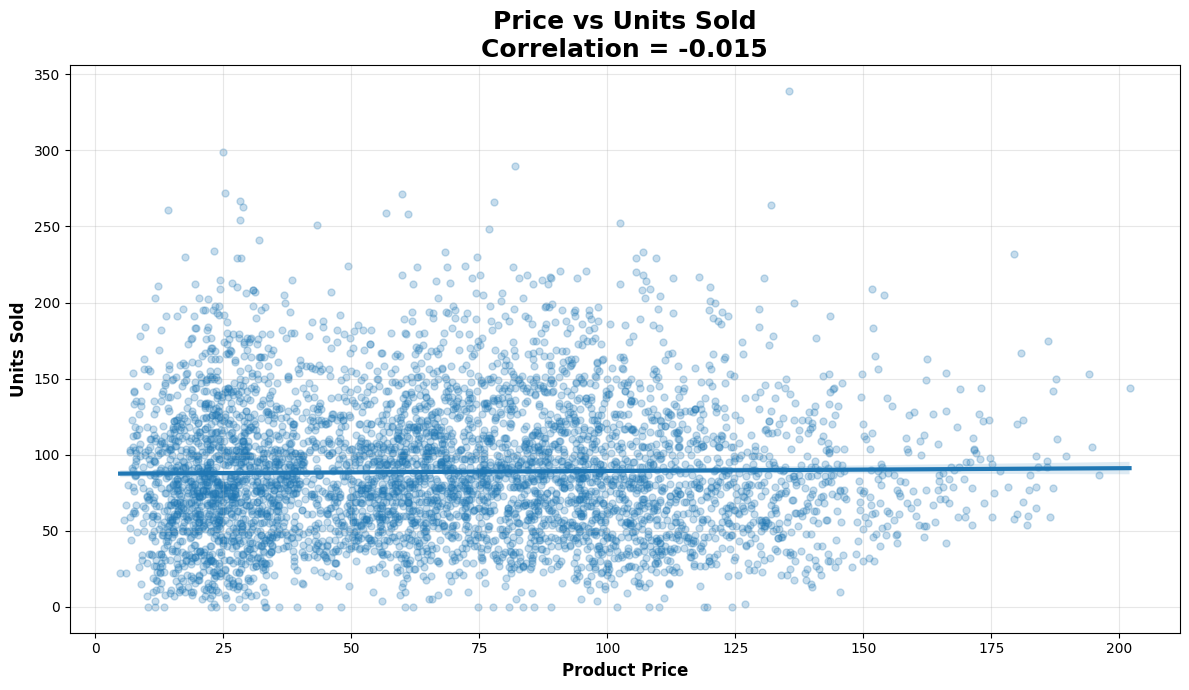

In [374]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_price_vs_sales(df):

    sample_df = df.sample(
        min(5000, len(df)),
        random_state=42
    )

    correlation = df['Price'].corr(df['Units Sold'])

    plt.figure(figsize=(12, 7))

    sns.regplot(
        data=sample_df,
        x='Price',
        y='Units Sold',
        scatter_kws={
            'alpha': 0.25,
            's': 25
        },
        line_kws={
            'linewidth': 3
        }
    )

    plt.title(
        f'Price vs Units Sold\nCorrelation = {correlation:.3f}',
        fontsize=18,
        fontweight='bold'
    )

    plt.xlabel(
        'Product Price',
        fontsize=12,
        fontweight='bold'
    )

    plt.ylabel(
        'Units Sold',
        fontsize=12,
        fontweight='bold'
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


plot_price_vs_sales(df_clean)

#Dataset Inspection
| Metric            |  Value |
| ----------------- | -----: |
| Total Records     | 76,000 |
| Total Features    |     21 |
| Missing Values    |      0 |
| Duplicate Records |      0 |

#Data Quality

The dataset was found to be highly structured:

1.   No missing values
2.   No duplicate records
3.   Appropriate numerical and categorical data types
4.   No records were removed during the cleaning process

#year-wise Revenue

| Year |   Total Revenue |
| ---- | --------------: |
| 2022 | ₹201.23 Million |
| 2023 | ₹196.15 Million |
| 2024 |  ₹15.21 Million |

#Regional Analysis

| Region |         Revenue |
| ------ | --------------: |
| North  | ₹154.14 Million |
| East   |  ₹89.26 Million |
| West   |  ₹85.60 Million |
| South  |  ₹83.59 Million |

#category wise Sales Analysis

| Category    | Units Sold |
| ----------- | ---------: |
| Groceries   |  3,127,335 |
| Clothing    |  1,150,873 |
| Furniture   |    880,654 |
| Toys        |    834,679 |
| Electronics |    757,335 |

#Seasonality and Demand Analysis

| Season | Average Demand |  Total Demand |
| ------ | -------------: | ------------: |
| Summer |     **112.86** |     2,076,539 |
| Autumn |         103.42 |     1,882,298 |
| Winter |         103.41 | **2,171,530** |
| Spring |          97.70 |     1,797,737 |



*   Sunny weather → Highest Demand
*   Snowy weather → Lowest Demand

